Прежде, чем приступать к этому ноутбуку вспомните/изучите в чем вообще суть языковых моделей.  

> Напоминаю, что в этом задании **МОЖНО ИСПОЛЬЗОВАТЬ БЯМ**.

Тут можно обойтись и без мощностей, потратьте время на то, чтобы разобраться в теме.
***
**[ВОТ ТУТ](https://lena-voita.github.io/nlp_course/seq2seq_and_attention.html) ЕСТЬ ЗАМЕЧАТЕЛЬНЫЙ КУРС, В НЕМ ЖЕ ЕСТЬ ЗАНЯТИЕ И ПО МЕХАНИЗМУ ВНИМАНИЯ, ОЧЕНЬ СОВЕТУЮ!**
***

# Введение и данные

В этой домашке вы сами попробуете **реализовать механизм внимания** и посмотреть «внутрь» него.

Мы будем смыслово продолжать следующую домашку, рассматривая **задачу генерации описания для статей**, но уже с использованием нового метода (данные те же, можете их почистить так же, как и в прошлой дз).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import WordPunctTokenizer
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from IPython.display import clear_output
from random import sample
from tqdm import trange

from tqdm.auto import tqdm
from collections import defaultdict, Counter
from queue import Queue

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
df = pd.read_csv('works_AI_2025.csv', usecols=['id', 'abstract', 'display_name'])
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.sample(5)

(73314, 3)


,id,abstract,display_name
58648,https://openalex.org/W7108463084,Zero-shot text classification effectively alle...,CLIPCMIC: a zero-shot text classification fram...
53179,https://openalex.org/W4415769653,This study aimed to utilize AI tools to create...,Visual language learning: Exploring the effect...
41262,https://openalex.org/W4412887917,The emergence of Large Language Models (LLMs) ...,Asymmetric Conflict and Synergy in Post-traini...
19562,https://openalex.org/W4411113044,The rise of Generative AI has led to a surge i...,AiMNLP@DravidianLangTech 2025: Unmask It! AI-G...
11276,https://openalex.org/W4413893647,"The increasing demand for privacy-preserving, ...",FairSYN-Edu a diffusion-based model for fair a...


In [ ]:
lines = df.apply(lambda row: row['display_name'] + ' ; ' + row['abstract'].replace("\n", ' '), axis=1).tolist()
sorted(lines, key=len)[-1:][0][:350]

'Correction: AI-driven framework for automated competency formalization: from professional standards to adaptive learning outcomes ; The of professional competency formulation and educational outcome design in higher education has emerged as a transformative approach, driven by the integration of sophisticated educational frameworks and advanced tec'

In [ ]:
tokenizer = WordPunctTokenizer()
lines = [' '.join(tokenizer.tokenize(line.lower())) for line in lines]
sorted(lines, key=len)[-1:][0][:350]

'correction : ai - driven framework for automated competency formalization : from professional standards to adaptive learning outcomes ; the of professional competency formulation and educational outcome design in higher education has emerged as a transformative approach , driven by the integration of sophisticated educational frameworks and advance'

Ранее вы работали с нейронками для генерации на уровне символов, в этой домашке поработаем **на уровне слов**. Соберем все токены, _будем словом считать то, что отделено пробелом_.

In [ ]:
BOS, EOS, UNK, PAD = '<BOS>', '<EOS>', '<UNK>', '<PAD>'
all_tokens = [BOS, EOS, UNK, PAD]
for line in lines:
    all_tokens.extend(line.split())
# не хило)
print(len(all_tokens))

17656759


Теперь соберем наш словарь (**из токена в индекс и из индекса в токен**).

In [ ]:
# TODO: создайте соответсвующие словари

tokens = sorted(set(all_tokens))
token_to_id = {token: idx for idx, token in enumerate(tokens)}
id_to_token = {idx: token for idx, token in enumerate(tokens)}
n_tokens = len(tokens)

In [ ]:
print(token_to_id[BOS], token_to_id[EOS], token_to_id[UNK], token_to_id[PAD])

9832 9833 9835 9834


Ну и вспомогательная функция как и в прошлый раз

In [ ]:
def to_matrix(lines, max_len=64, pad_id=token_to_id[PAD]):
    matrix = np.full((len(lines), max_len), pad_id, dtype=np.int64)
    for i, line in enumerate(lines):
        ids = [token_to_id.get(t, token_to_id[UNK]) for t in line.split()[:max_len]]
        ids = [token_to_id[BOS]] + ids + [token_to_id[EOS]]
        matrix[i, :min(len(ids), max_len)] = ids[:max_len]
    return torch.tensor(matrix)

In [ ]:
dummy_lines = [
    ' winx',
    ' if your hand is warm in mine',
    ' it ll give us greater power',
]
print(to_matrix(dummy_lines))

tensor([[  9832,   9835,   9833,   9834,   9834,   9834,   9834,   9834,   9834,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
           9834],
        [  9832,  69618, 154247,  64330,  74393, 150513,  70795,  91134,   9833,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
           9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,   9834,
          

# Attention

Теперь давайте самомтоятельно реализуем самый простой attention. Мы будем его использовать для нашей **RNN** модели из прошлой работы)

**Зачем нужно внимание?**

Рекуррентные сети обрабатывают последовательность шаг за шагом, сохраняя информацию в скрытом состоянии $h_t$. Теоретически $h_t$ содержит всю историю, но на практике градиенты затухают, и модель «забывает» начало длинных текстов.

**Self-Attention** решает эту проблему, позволяя каждому токену напрямую «смотреть» на все предыдущие токены. Для каждого шага $t$ мы вычисляем взвешенную сумму всех скрытых состояний
$$H = [h_1, \dots, h_T] : c_t = \sum_{j=1}^T \alpha_{t,j}h_j,$$
где веса $\alpha_{t,j}$ показывают, насколько важен токен $j$ для предсказания токена $t$.

Вместо явного суммирования используется **матричная форма** (_**Scaled Dot-Product Attention**_). Сначала проецируем скрытые состояния в три пространства:
$$Q = HW_Q, K = HW_K, V = HW_V,$$
где $W_Q, W_K, W_V \in \mathbb{R}^{d \times d}$ — обучаемые матрицы (`nn.Linear`).

Далее вычисляем «сырые» важности как скалярные произведения запросов и ключей, масштабируем на $\sqrt{d}$ (чтобы градиенты не взрывались) и нормализуем через _softmax_:
$$Attention(Q, K, V) = softmax\left( \frac{QK^T}{\sqrt{d_k}} \right) V.$$

**Causal Mask** (каузальная маска)

При обучении языковой модели мы не можем «подглядывать» в будущее. Поэтому для каждой позиции $t$ обнуляем (или зануляем логитами) все веса $\alpha_{t,j}$ при $j > t$. Матрица маски выглядит так:
$$M = \begin{pmatrix} 1 & 0 & 0 & \dots \\ 1 & 1 & 0 & \dots \\ 1 & 1 & 1 & \dots \\ \vdots & \vdots & \vdots & \ddots \end{pmatrix}.$$
Перед softmax к нулевым элементам прибавляется $-\infty$ (или $-10^9$ ), чтобы softmax обнулил их.

In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, hid_size, scale=True):
        super().__init__()
        # TODO: создайте три линейных слоя для проекций Q, K, V

        self.query = nn.Linear(hid_size, hid_size, bias=False)
        self.key = nn.Linear(hid_size, hid_size, bias=False)
        self.value = nn.Linear(hid_size, hid_size, bias=False)

        self.scale = hid_size ** -0.5 if scale else 1.0


    def forward(self, hidden_states, causal_mask=None):
        """
        hidden_states: [batch, seq_len, hid_size]
        causal_mask:   [batch, seq_len, seq_len] или [1, seq_len, seq_len] (bool)
        """
        # TODO: вычислите Q, K, V

        Q = self.query(hidden_states)
        K = self.key(hidden_states)
        V = self.value(hidden_states)

        # TODO: скалярные произведения и масштабирование
        scores = torch.bmm(Q, K.transpose(1, 2)) * self.scale  # [batch, seq_len, seq_len]

        if causal_mask is not None:
            # маска обычно bool: True = можно смотреть, False = нельзя
            # приводим к float и добавляем -1e9 где маска False
            scores = scores.masked_fill(causal_mask == 0, -1e9)

        # TODO: softmax и произведение
        attn_weights = F.softmax(scores, dim=-1)   # [B, L, L]
        context = torch.bmm(attn_weights, V)  # [B, L, H]

        return context, attn_weights

In [ ]:
dummy_h = torch.randn(2, 5, 32)
attn = CausalSelfAttention(32)
ctx, w = attn(dummy_h)
assert ctx.shape == (2, 5, 32)
assert w.shape == (2, 5, 5)
assert torch.allclose(w.sum(dim=-1), torch.ones(2, 5), atol=1e-5)
assert torch.all(w >= 0) and torch.all(w <= 1)

Теперь применим наш слой в обучении уже известной архитектуры

# Модель и обучение

Будем использовать ту же **рекурентную архитектуру** (можете перенести части из прошлого дз), но добавим в нее слой _attention_.

In [ ]:
class AttentionRNNLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=256, hid_size=512, num_layers=2):
        super().__init__()

        self.n_tokens  = n_tokens
        self.emb_size  = emb_size
        self.hid_size  = hid_size
        self.num_layers = num_layers

        # эмбеддинги
        self.emb = nn.Embedding(n_tokens, emb_size)

        # RNN/GRU/LSTM
        self.gru = nn.GRU(
            input_size=emb_size,
            hidden_size=hid_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Self-Attention
        self.attn = CausalSelfAttention(hid_size)
        self.norm = nn.LayerNorm(hid_size)

        # для получения логитов
        self.output = nn.Linear(hid_size, n_tokens)

    def __call__(self, input_ix, return_attn_weights=False):
        """
        :param input_ix: [batch_size, sequence_length]
        :returns: logits [batch_size, sequence_length, n_tokens]
        """
        batch_size, seq_len = input_ix.shape

        # эмбеддинги
        x = self.emb(input_ix)

        # RNN/GRU/LSTM
        h, _ = self.gru(x)  # h: [B, L, hid_size]

        # маска
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=h.device)).bool()
        causal_mask = causal_mask.unsqueeze(0)  # [1, L, L]

        # Self-Attention
        h_attn, attn_weights = self.attn(h, causal_mask=causal_mask)  # context: [B, L, hid_size]
        context = self.norm(h + h_attn)

        # логиты
        logits = self.output(context)

        if return_attn_weights:
            return logits, attn_weights
        return logits

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        tokens_list = prefix.split()
        ids = [token_to_id.get(t, token_to_id[UNK]) for t in tokens_list]
        prefix_ix = torch.tensor([ids], dtype=torch.int64).to(device)

        with torch.no_grad():
            logits = self(prefix_ix)
            probs = torch.softmax(logits[0, -1], dim=-1).cpu().numpy()
        return dict(zip(tokens, probs))

Все также считаем функцию потерь, но не забываем **обработать вспомогательные токены**.

In [ ]:
def compute_loss(model, input_ix):
    logits = model(input_ix[:, :-1])
    targets = input_ix[:, 1:]

    loss = F.cross_entropy(logits.reshape(-1, n_tokens), targets.reshape(-1), reduction='none')
    loss = loss.view(targets.shape)

    # игнорируем PAD и всё, что после первого EOS
    pad_mask = (targets != token_to_id[PAD])
    eos_cum = torch.cumsum(targets == token_to_id[EOS], dim=1) > 0
    valid = pad_mask & ~eos_cum

    return (loss * valid).sum() / valid.sum()

def score_lines(model, dev_lines, batch_size):
    """ computes average loss over the entire dataset """
    dev_loss_num, dev_loss_len = 0., 0.
    with torch.no_grad():
        for i in range(0, len(dev_lines), batch_size):
            batch_ix = to_matrix(dev_lines[i: i + batch_size]).to(device)
            dev_loss_num += compute_loss(model, batch_ix).item() * len(batch_ix)
            dev_loss_len += len(batch_ix)
    return dev_loss_num / dev_loss_len

def generate(model, prefix=BOS, temperature=1.0, max_len=100):
    """
    Samples output sequence from probability distribution obtained by model
    :param temperature: samples proportionally to model probabilities ^ temperature
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    with torch.no_grad():
        while True:
            token_probs = model.get_possible_next_tokens(prefix)
            tokens, probs = zip(*token_probs.items())
            if temperature == 0:
                next_token = tokens[np.argmax(probs)]
            else:
                probs = np.array(probs, dtype='float64')
                probs = np.clip(probs, 1e-12, 1.0)
                probs = probs ** (1. / temperature)
                probs /= probs.sum()
                next_token = np.random.choice(tokens, p=probs)

            if next_token not in (BOS, EOS, '_EOS_') and not prefix.endswith(' '):
                prefix += ' '
            prefix += next_token
            if next_token == EOS or len(prefix) > max_len: break
    return prefix

In [ ]:
train_lines, dev_lines = train_test_split(lines, test_size=0.2, random_state=42)

**Вам нужно обучить модель так, чтобы генерация была осмысленной**

In [ ]:
batch_size = 64
max_len = 64
steps = 5000
lr = 3e-4
grad_clip = 1.0
score_dev_every = 250

model_rnn = AttentionRNNLanguageModel(
    n_tokens = n_tokens,
    emb_size = 256,
    hid_size = 512,
    num_layers = 2
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)

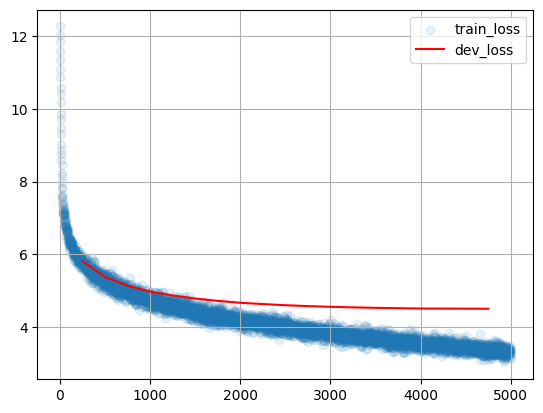

Scoring dev...
#4999 Dev loss: 4.509


100%|██████████| 5000/5000 [1:35:01<00:00,  1.14s/it]

<BOS> a multi - modal attention - based spatial - temporal network for anomaly detection in vision - language


In [ ]:
train_history, dev_history = [], []

for i in trange(steps):
    model.train()
    batch_lines = sample(train_lines, batch_size)
    batch_ix = to_matrix(batch_lines, max_len=max_len).to(device)

    loss = compute_loss(model, batch_ix)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    opt.step()

    train_history.append((i, loss.item()))

    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()

    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])
        for _ in range(1):
            print(generate(model, temperature=0.9))

In [ ]:
for i in range(10):
    print(generate(model, temperature=0.5))

<BOS> a novel approach for enhancing the efficiency of solar panel power generation through a hybrid deep
<BOS> a novel approach to improving the performance of ai - generated text detection in open - ended environments
<BOS> a study on the development and evaluation of ai - supported tools for english writing in english
<BOS> the influence of ai on education : teaching quality evaluation and evaluation ; artificial intelligence
<BOS> a novel approach to enhance the transferability of adversarial attacks against adversarial attacks
<BOS> the role of artificial intelligence in enhancing customer experience : a systematic literature review
<BOS> quantum computing and its applications in modern medicine ; this paper presents a novel quantum
<BOS> a survey on data - driven integration of ai - driven learning tools and platforms in educational
<BOS> evaluating the role of ai in learning and management strategies in the context of artificial intelligence
<BOS> ai - powered language model for

In [ ]:
for i in range(10):
    print(generate(model, 'Artificial', temperature=0.5))

Artificial boundaries . the study aims to identify the strengths and weaknesses of the aforementioned
Artificial in situ hybridization ( hg ) ; in this paper , we present a novel approach to the non - destructive
Artificial and their applications in the u . s . corporations : none . the purpose : this study is to
Artificial in coq . this paper examines the philosophical foundations and methodological foundations ,
Artificial across all sectors , including librarianship , notes , and lung cancer , alzheimer ' s disease
Artificial in the context of context - specific context of reference quantum molecules . we investigate
Artificial in a non - markovian non - markovian non - markovian non - markovian non - markovian non -
Artificial in the metaverse , and the metaverse is the metaverse , and the metaverse sector . metaverse
Artificial for electronic computers , electronic computers and electronic services , electronic commerce
Artificial in a wide range of applications , including fraud 

In [ ]:
torch.save(model.state_dict(), 'modelRNNAttentStateDict.pt2')


In [ ]:
torch.save(model, 'modelRNNAttent.pt2')

**Напишите пару слов о качестве модели**

Что-ж. Я удивлен, не думал что моделька будет генерить так хорошо. В целом, видимо внимание реально помогает модели лучше понять связи между словами. Также у модели есть устойчивый паттерн - после ';' она начинает генерить описание статьи. Блин, это реально работает, абалдеть...


Качество, мне кажется, неплохое. По словам клода у небольших нормально обученных языковых моделей perplexity < 50, а у RNN&Attention - около 90 получилось (Как я понял, перплексити считается, возведением экспоненты в степень loss, e^(4.509) ~ 91) В целом небольшое отставание, хотя оно все-таки есть.

Но иногда моделька повторяет одни и те же словосочетания. Из-за того, что словарь слишком большой, из-за чего моделька "много сил" (параметров) тратит на понимание редких слов, вместо того, чтобы лучше изучать взаимосвязи частых слов. Также, возможно, если дообучить модельку еще сколько-то эпох, то она тоже станет лучше.

# Визуализация и интерпретация

Реализовать мы реализовали, теперь очень важно посмотреть, а что это за зверь вообще такой и как работает)

Попробуем «подглядеть», куда смотрит модель (на что направлено внимание).

_У вас должны получиться вертикальные полосы (что это значит?), а также нули в верхнем треугольнике (проверка, что вы в будущее не смотрите)_

##### Было

In [67]:
import seaborn as sns

def generate_with_attention(model, prefix=BOS, temperature=1.0, max_len=30, device='cpu'):

    model.eval()
    current_text = prefix
    generated_tokens = []
    attn_weights_list = []

    with torch.no_grad():
        for _ in range(max_len):
            current_tokens_split = current_text.split()
            seq_len_actual = len(current_tokens_split)

            input_ix = torch.as_tensor(to_matrix([current_text]), dtype=torch.int64).to(device)
            logits, attn_weights = model(input_ix, return_attn_weights=True)
            last_step_weights = attn_weights[0, -1, :seq_len_actual].cpu().numpy() #
            attn_weights_list.append(last_step_weights)

            probs = torch.softmax(logits[0, -1] / max(temperature, 1e-7), dim=-1).cpu().numpy()
            if temperature == 0:
                next_idx = np.argmax(probs)
            else:
                scaled = probs ** (1.0 / temperature)
                scaled /= scaled.sum()
                next_idx = np.random.choice(len(scaled), p=scaled)

            next_token = tokens[next_idx]
            generated_tokens.append(next_token)

            current_text += (" " if not current_text.endswith(" ") and current_text != "" else "") + next_token

            if next_token == EOS:
                break

    T = len(generated_tokens)
    attn_matrix = np.zeros((T, T))
    for i in range(T):
        src_len = len(attn_weights_list[i])
        attn_matrix[i, :min(src_len, T)] = attn_weights_list[i][:T]

    return generated_tokens, attn_matrix


def draw_attention(tokens, attn_weights, title="Self-Attention Weights", max_display=25):

    if len(tokens) > max_display:
        tokens = tokens[:max_display]
        attn_weights = attn_weights[:max_display, :max_display]

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        attn_weights,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        cbar_kws={'label': 'Attention weight'},
        vmin=0, vmax=1,
        linewidths=0.3,
        linecolor='lightgray'
    )

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Previous tokens (Source)", fontsize=12)
    plt.ylabel("Generated tokens (Target)", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

##### Исправил.

Сначала мне на генерации с attention выдавалась полная бесмысслица. Модель чему-то переходила на вообще другой язык и генерировала последовательность слов не связную вообще. Я попробовал убрать из словаря лишние редкие токены и обучить заного в другом колабе - не помогло. В итоге я спросил Claude Code, он посоветовал изменить следующую вещь:

Оказывается, мы же создаем массив сразу полной размерности и заполняем его токенами `<PAD>`. И когда мы загоняем все наши слова в модель, то она, по сути, предсказывает логиты для каждого из 64 токенов.

Но, если наша модель научилась предсказывать адекватные токены для тех, что ... То для токена после `<EOS>` и кучи `<PAD>` модель генерит дичь. Просто потому, что она не понимает, что там генерить. И я на это попался. Думал, что модель как-то не так работает. (Думал хм-хм, почему же у меня она на обычном инференсе генерит норм, а в функции generate_with_attention белиберда получается...) А оказывается все решалось тем, чтобы просто смотреть на сгенерированные логиты не для последнего токена в последовательности, а для следующего по счету (по порядку предсказания). Ура, теперь модель генерит все как надо!



In [68]:
def generate_with_attention(model, prefix='a novel approach',
                            temperature=1.0, max_len=30, device='cpu'):
    model.eval()
    current_text = prefix
    generated_tokens = []
    attn_weights_list = []

    with torch.no_grad():
        for _ in range(max_len):
            current_tokens_split = current_text.split()
            seq_len_actual = len(current_tokens_split)

            input_ix = torch.as_tensor(
                to_matrix([current_text]), dtype=torch.int64
            ).to(device)

            logits, attn_weights = model(input_ix, return_attn_weights=True)

            # вот туть ошибка была
            last_step_weights = attn_weights[
                0, seq_len_actual, :seq_len_actual
            ].cpu().numpy()
            attn_weights_list.append(last_step_weights)

            # и вот туть ошибка была
            probs = torch.softmax(
                logits[0, seq_len_actual] / max(temperature, 1e-7), dim=-1
            ).cpu().numpy()

            if temperature == 0:
                next_idx = np.argmax(probs)
            else:
                scaled = probs ** (1.0 / temperature)
                scaled /= scaled.sum()
                next_idx = np.random.choice(len(scaled), p=scaled)

            next_token = tokens[next_idx]
            generated_tokens.append(next_token)

            current_text += ' ' + next_token

            if next_token == EOS:
                break

    T = len(generated_tokens)
    attn_matrix = np.zeros((T, T))
    for i in range(T):
        src_len = len(attn_weights_list[i])
        attn_matrix[i, :min(src_len, T)] = attn_weights_list[i][:T]

    return generated_tokens, attn_matrix

##### Тест модели

في and ; algorithm gt ; sasak n aceh في . . . cg ; . n preview still preview 2024 > according n .


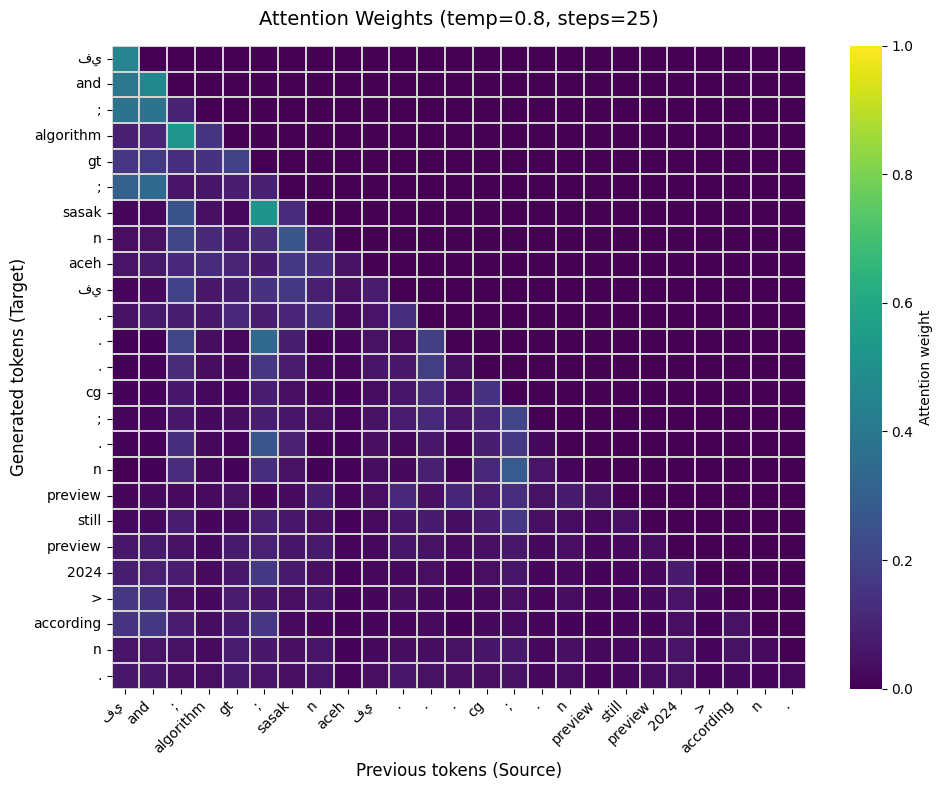

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

**ТУТ ВАШИ СЛОВА ПРО ИНТЕРПРЕТАЦИЮ. ТАК КАК ЗАДАНИЕ В ЭТОМ И СОСТОИТ, ТО ИНТЕРПРЕТАЦИЯ ДОЛЖНА БЫТЬ АДЕКВАТНОЙ, НАДО ПРОВЕСТИ РАЗНЫЕ ЭКСПЕРИМЕНТЫ И ДАТЬ КАКОЙ-ТО ВЫВОД**

Тут моделька больше внимания уделяет первому токену в последовательности, чем трансформер.

# Модель без RNN, обучение и визуализация

Теперь попробуем классическую архитектуру `Attention` + `Feed Forward`. Мы воспользуемся нашим **уже реализованным вниманием**.

Попробуем сделать так:
* **Блок декодера** для трансформера: `Attention` + `FeedForward` (`Linear` + `ReLu` + `Linear` + `Dropout`)
* Его применение (несколько таких блоков) с **позиционным кодированием** + голова для логитов.

Для всего написан шаблон, следуйте ему.

_Эта модель обучается дольше по шагам, но по скорости она гораздо быстрее_

**Вам нужно обучить модель так, чтобы генерация была осмысленной**

In [ ]:
class TransformerDecoderBlock(nn.Module):
    def __init__(self, d_model, d_ff=256, dropout=0.1):
        super().__init__()
        # используем наш CausalSelfAttention
        self.attn = CausalSelfAttention(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask=None, return_attn=False):
        # примените внимание к нормализованномц входу
        attn_out, attn_weights = self.attn(self.norm1(x), causal_mask=causal_mask)
        x = x + self.dropout(attn_out)
        # ff к нормализованному x
        ff_out = self.ff(self.norm2(x))
        x = x + self.dropout(ff_out)

        if return_attn:
            return x, attn_weights
        return x


class TransformerOnlyLanguageModel(nn.Module):
    def __init__(self, n_tokens, d_model=128, d_ff=256, num_layers=2, max_pos=128, dropout=0.1, tokens_list=None):
        super().__init__()
        self.n_tokens   = n_tokens
        self.tokens_list = tokens_list if tokens_list is not None else tokens
        self.max_pos    = max_pos

        # токенные + позиционные эмбеддинги, это важно для трансформера, чтобы он знал порядок слов
        self.emb = nn.Embedding(n_tokens, d_model)
        self.pos_emb = nn.Embedding(max_pos, d_model)

        # трансформер-блоки
        self.layers = nn.ModuleList([
            TransformerDecoderBlock(d_model, d_ff=d_ff, dropout=dropout)
            for _ in range(num_layers)
        ])

        # Финальные нормализация и проекция в логиты
        self.norm    = nn.LayerNorm(d_model)
        self.head    = nn.Linear(d_model, n_tokens)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ix, return_attn_weights=False, layer_idx=-1):

        batch_size, seq_len = input_ix.shape
        device = input_ix.device

        # токен + позиция
        positions = torch.arange(seq_len, device=device)
        x = self.emb(input_ix) + self.pos_emb(positions.clamp(max=self.max_pos - 1))
        x = self.dropout(x)

        # маска
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=device)).bool()

        target_layer = layer_idx if layer_idx >= 0 else len(self.layers) - 1
        selected_attn = None

        # через блоки
        for i, layer in enumerate(self.layers):
            is_target = (i == target_layer)

            if return_attn_weights and is_target:
                x, attn_weights = layer(x, causal_mask=causal_mask, return_attn=True)
                selected_attn = attn_weights
            else:
                x = layer(x, causal_mask=causal_mask)

        x = self.norm(x)
        logits = self.head(x)

        if return_attn_weights:
            return logits, selected_attn
        return logits

    def get_possible_next_tokens(self, prefix, temperature=1.0, max_len=100):
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64)
        device = next(self.parameters()).device
        prefix_ix = prefix_ix.to(device)

        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()
        return dict(zip(self.tokens_list, probs))

In [ ]:
batch_size = 64
max_len = 64
steps = 10000
lr = 1e-4
grad_clip = 1.0
score_dev_every = 250

model = TransformerOnlyLanguageModel(
    n_tokens=n_tokens,
    d_model=128,
    d_ff=256,
    num_layers=2,
    dropout=0.1,
    tokens_list=tokens
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)

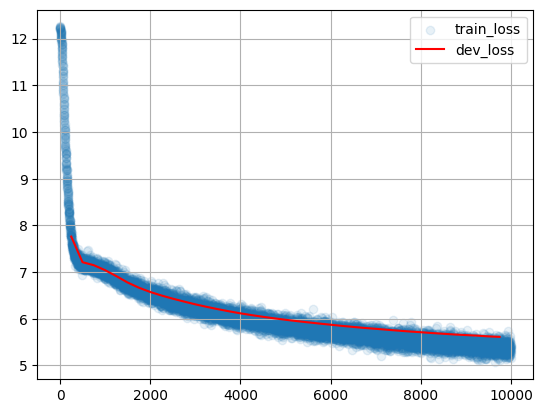

Scoring dev...
#9999 Dev loss: 5.597


100%|██████████| 10000/10000 [1:17:40<00:00,  2.15it/s]

<BOS> ai rivers findings droplet in lastly keywords os 2025 problems ' pasien confront skarn concise management


In [ ]:
train_history, dev_history = [], []

for i in trange(steps):
    model.train()
    batch_lines = sample(train_lines, batch_size)
    batch_ix = to_matrix(batch_lines, max_len=max_len).to(device)

    loss = compute_loss(model, batch_ix)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    opt.step()

    train_history.append((i, loss.item()))

    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()

    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])
        for _ in range(1):
            print(generate(model, temperature=0.9))

In [ ]:
torch.save(model, 'modelka.pt2')

In [ ]:
torch.save(model.state_dict(), 'modelka_sd.pt2')

In [ ]:
for i in range(10):
    print(generate(model, temperature=0.7))

<BOS> 2025 applications des ye opportunities topologique . 2025 . this images e av as attacks from ; and
<BOS> in yu based ; healthcare using and : in media efficiency . in : tasks e from vehicles services in
<BOS> el inefficiencies iot from quality and ; become as fail with from , and : , i machines to agents
<BOS> - , innovation ; augments at aspects using prediction attacks en : in networks . v3 in opinions
<BOS> prediction a from 2025 ml and ; in : introduced users tasks , and over using support , their to
<BOS> , forests ml 2025 for food ? ai subtypes mri yu so : over . ? di sup en , avec di , : li association
<BOS> scp scp back ; : effectively : , - . , : , , 2025 the . i countermeasures in , i , and remains ,
<BOS> 2025 cancers data . configurations scholar are profitability for . benefit aquatic is tasks in as
<BOS> ? updates and and ai km for systems in screening fraud as in : require generated ; detection patients
<BOS> paths estate and and ( : there i a df knowledge in from 

In [ ]:
for i in range(2):
    print(generate(model, temperature=0.5))

<BOS> by i i 2025 en ? from in ; , ( from - systems : b agents doi . agents , as , - , , , , , i , , ,
<BOS> in and : ; in — and in , , ai in : and , and , , and , , , , , , , , , , , , , , , , , , , , , ,


In [61]:
for i in range(3):
    print(generate(model, 'AI - based', temperature=0.8))

AI - based in isolation image collaboratively anomaly , cefr dags en deng dans scp : particle , ; p kanojia
AI - based yu district co di benefit e as kan ml native : pathology ; magmatism over face by , text agents
AI - based marketing ; scp texas en en training di materi enhance da become dan is nat in in - nlp using


**ПАРУ СЛОВ ПРО МОДЕЛЬ**

У трансформера ошибка 5.597 (perplexity около 270) против 4.509 у RNN&Attention. При бОльшем времени на обучение (бОльшем числе "эпох") результат получился хуже.

Причина, как мне кажется, в том, что масштаб (мощность) модели не совсем соответсвует размеру словаря. Моделька менее мощная, чем, видимо, следовало бы. Либо словарь слишком большой. Возможно, если убрать часть токенов из словаря, то моделька станет работать лучше. Или, если увеличить d_ff или d_model и увеличить количество "эпох", то моделька тоже может стать точнее. Хотя, не факт. Если в словаре много редких слов, то проще просто удалить эти слова, и обучить модельку размера как сейчас.

А RNN&Attention выигрывает здесь за счет бОльшего размера скрытого состояния (hid_size = 512)

Теперь тоже это визуализируем

In [ ]:
def generate_with_attention(model, prefix='a novel approach', temperature=1.0, max_len=30, device='cpu', layer_idx=-1):

    model.eval()
    current_text = prefix
    generated_tokens = []
    attn_weights_list = []

    with torch.no_grad():
        for _ in range(max_len):
            current_tokens_split = current_text.split()
            seq_len_actual = len(current_tokens_split)

            input_ix = torch.as_tensor(to_matrix([current_text]), dtype=torch.int64).to(device)

            # выбираем нужный слой
            logits, attn_weights = model(input_ix, return_attn_weights=True, layer_idx=layer_idx)

            last_step_weights = attn_weights[0, seq_len_actual, :seq_len_actual].cpu().numpy()
            attn_weights_list.append(last_step_weights)

            probs = torch.softmax(logits[0, seq_len_actual] / max(temperature, 1e-7), dim=-1).cpu().numpy()
            if temperature == 0:
                next_idx = np.argmax(probs)
            else:
                scaled = probs ** (1.0 / temperature)
                scaled /= scaled.sum()
                next_idx = np.random.choice(len(scaled), p=scaled)

            next_token = tokens[next_idx]
            generated_tokens.append(next_token)

            current_text += (" " if not current_text.endswith(" ") and current_text != "" else "") + next_token

            if next_token == EOS:
                break

    T = len(generated_tokens)
    attn_matrix = np.zeros((T, T))
    for i in range(T):
        src_len = len(attn_weights_list[i])
        attn_matrix[i, :min(src_len, T)] = attn_weights_list[i][:T]

    return generated_tokens, attn_matrix

In [ ]:
def generate_with_attention(model, prefix=BOS, temperature=1.0, max_len=30, device='cpu', layer_idx=-1):

    model.eval()
    current_text = prefix
    generated_tokens = []
    attn_weights_list = []

    with torch.no_grad():
        for _ in range(max_len):
            current_tokens_split = current_text.split()
            seq_len_actual = len(current_tokens_split)

            input_ix = torch.as_tensor(to_matrix([current_text]), dtype=torch.int64).to(device)

            # выбираем нужный слой
            logits, attn_weights = model(input_ix, return_attn_weights=True, layer_idx=layer_idx)

            last_step_weights = attn_weights[0, -1, :seq_len_actual].cpu().numpy()
            attn_weights_list.append(last_step_weights)

            probs = torch.softmax(logits[0, -1] / max(temperature, 1e-7), dim=-1).cpu().numpy()
            if temperature == 0:
                next_idx = np.argmax(probs)
            else:
                scaled = probs ** (1.0 / temperature)
                scaled /= scaled.sum()
                next_idx = np.random.choice(len(scaled), p=scaled)

            next_token = tokens[next_idx]
            generated_tokens.append(next_token)

            current_text += (" " if not current_text.endswith(" ") and current_text != "" else "") + next_token

            if next_token == EOS:
                break

    T = len(generated_tokens)
    attn_matrix = np.zeros((T, T))
    for i in range(T):
        src_len = len(attn_weights_list[i])
        attn_matrix[i, :min(src_len, T)] = attn_weights_list[i][:T]

    return generated_tokens, attn_matrix

###### Эксперименты

Тут сразу выводы, так как внизу довольно много картинок)

Итак, вывод:

RNN на большом объеме данных генерит гораздо лучше, чем трансформер. Тут, мне кажется, дело в слишком маленькой архитектуре трансформера. Словарь слишком большой и, если бы его урезать, то ситацуя могла бы поменяться. А так, возможно, если бы дообучить трансформер побольше, и взять сам трансформер побольше, то точность была бы выше.


Но, вот что я заметил: attention в обоих моделях имеет интересное свойство: большое "внимание" выделяется на две группы токенов:
1. Токены, расположенные в начале предложения. На последующих токенах модель ослабляет внимание. Как я понял, это сявзано с тем, что при малом количестве сгенерированных слов модельке больше не на что распределять внимание. Поэтому оно как-бы "концентрируется" на небольшом наборе слов. (Это при генерации первых слов). На матричке это отображается как пиксели, затухающие от диагонали к низу матрицы.
2. Токены после символа `;`. Тут моделька вдруг снова "просыпается" и выделяет вниманием первые токены после символа `;`. Наверное, это как раз связано с тем, что моделька как-бы "переключается" в режим генерации описания.


Еще, в отдельных генерациях attention часто обращает внимание на предлоги. Видимо, это помогает ему лучше понимать взаимосвязь слова на которое он смотрит с предыдущими словами.


Также, по маске в целом видно (из-за нулевых значений в верхнем треугольнике), что моделька не заглядывает в будущее - это хорошо.

we present a multi - agent deep learning framework for large language models ( llms ) are widely used to the integration of natural language


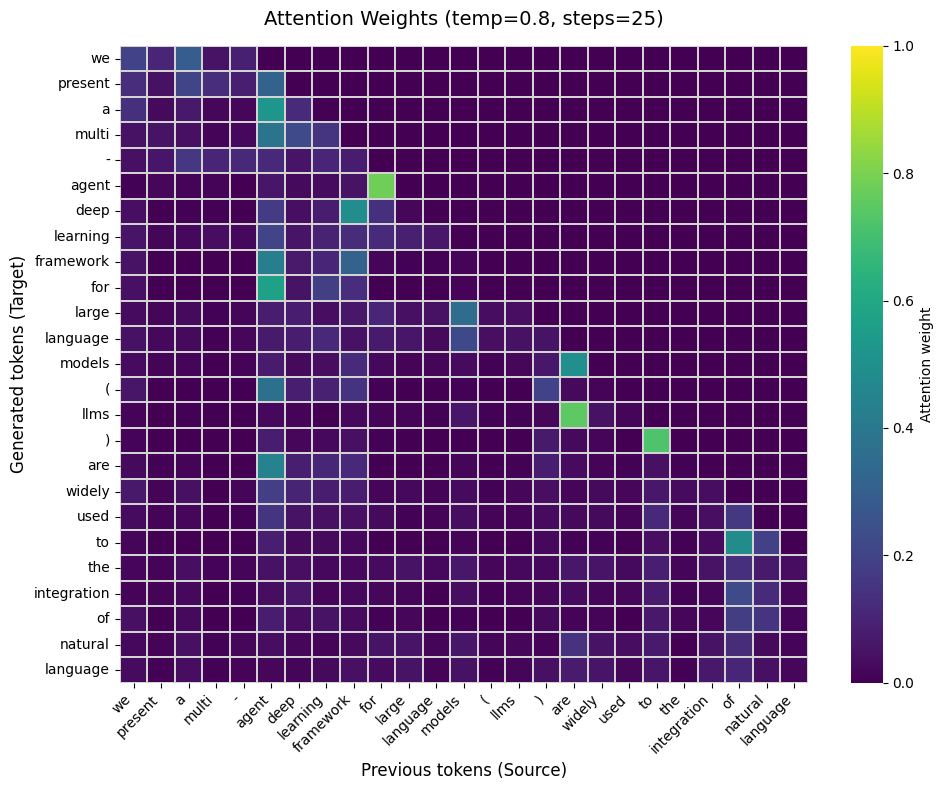

In [59]:
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

a method for federated learning - based knowledge graphs ; the rapid advancement of the internet of things ( iot ) are becoming increasingly important


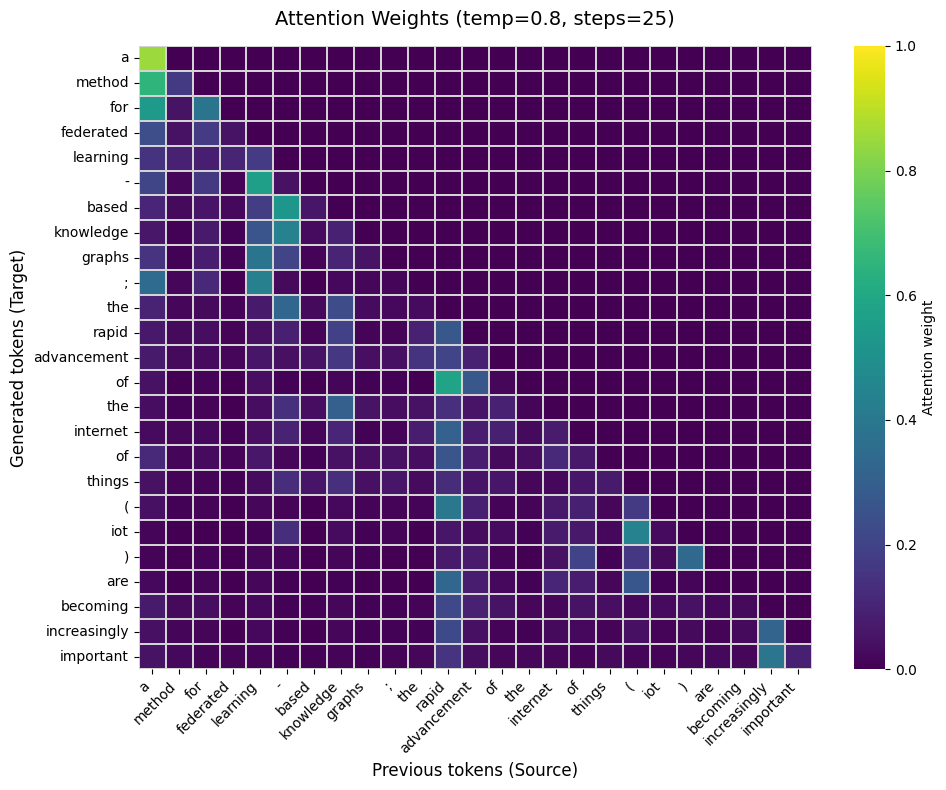

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

artifacts with ; geoffrey : users with employees from , , : , and - . prediction , engines , chen , chen accuracy projects


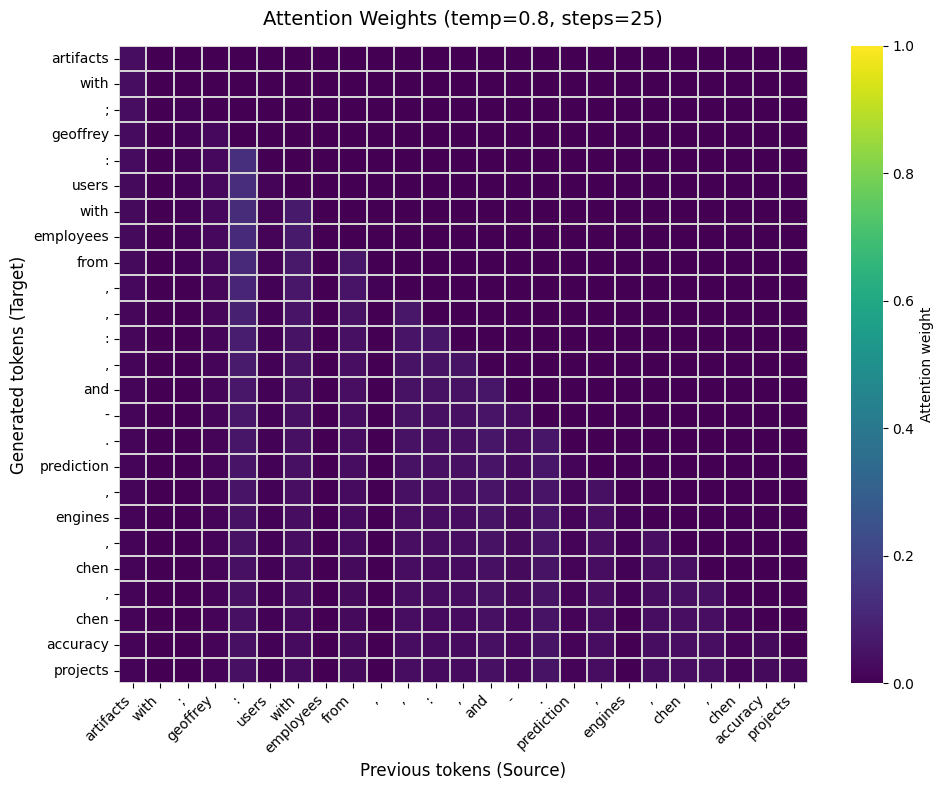

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

analysis of large language models and llms : a multi - domain knowledge ; the rapid development of the most important and medium in the


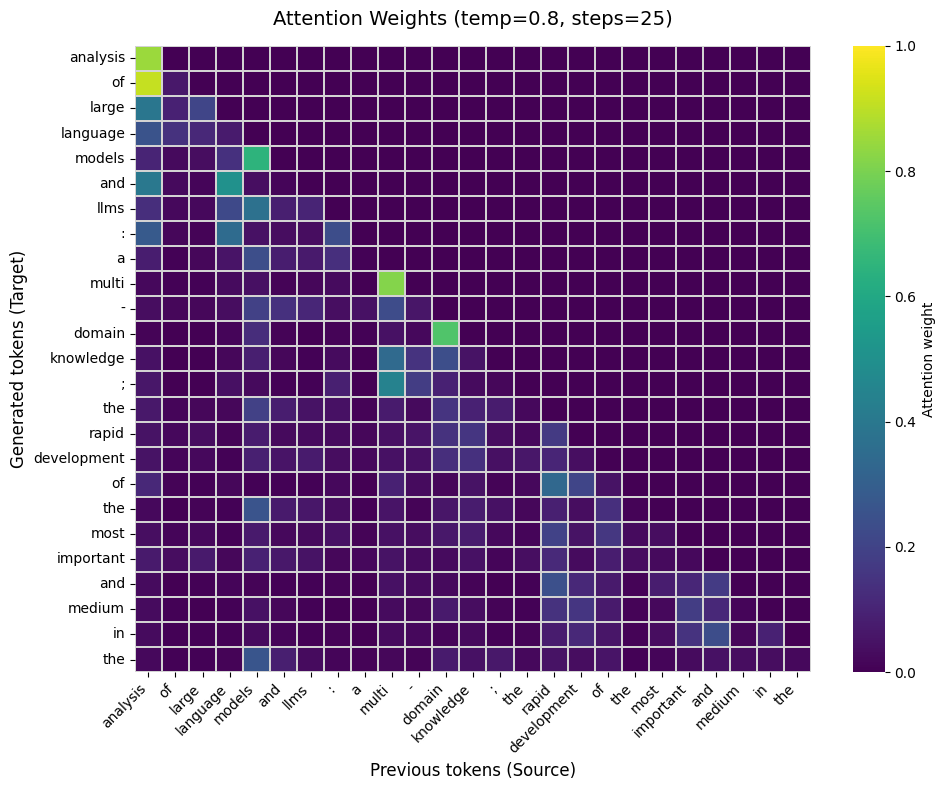

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

the impact of ai - driven poetry : a case study ; the advancement of the rapid growth of the development of artificial intelligence (


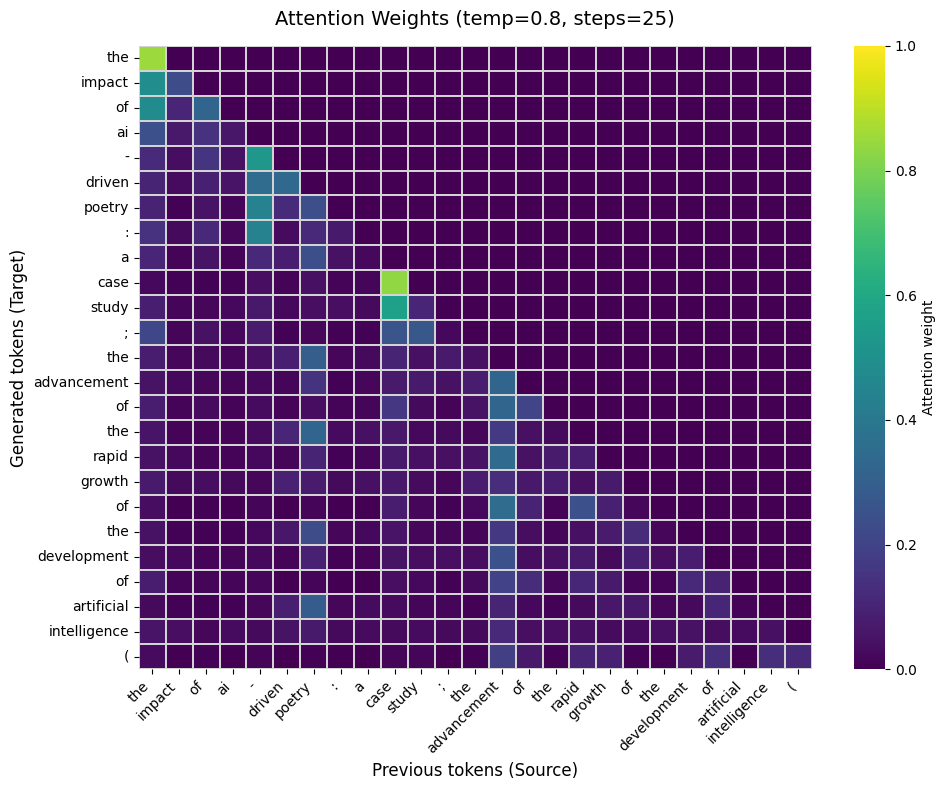

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

evaluation of the association for the internet of things ; the modern power ( volume ) is an important role in the half of the


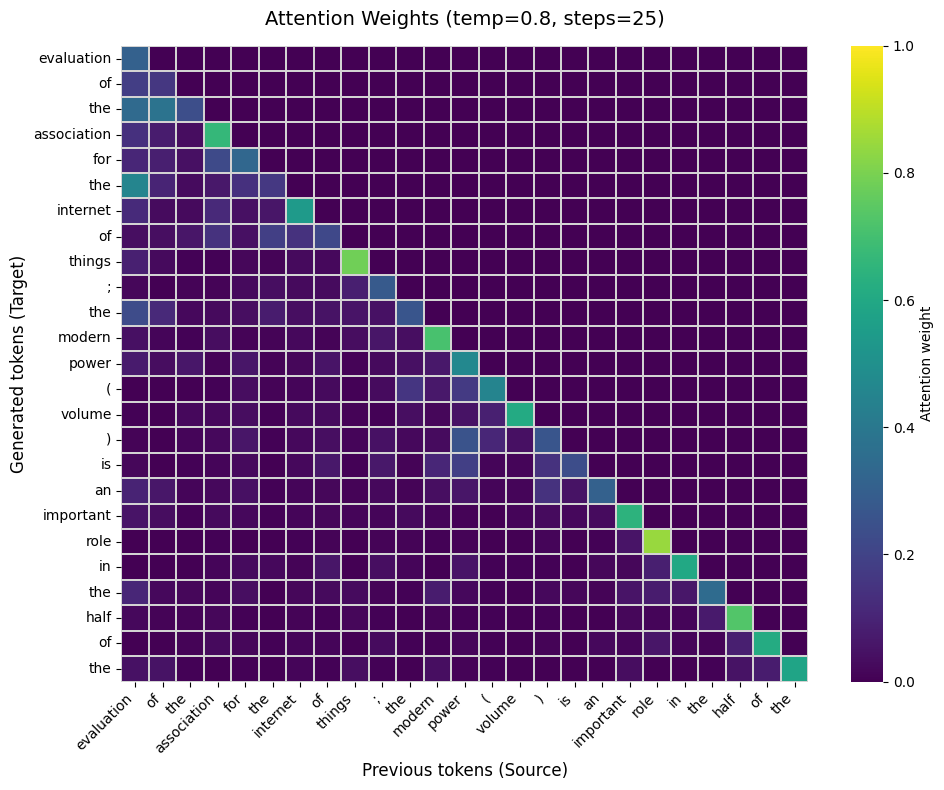

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=0
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

on a deep learning framework for assessment and dynamic analysis ; deep learning techniques have been proposed for distributed tasks due to the emerging of


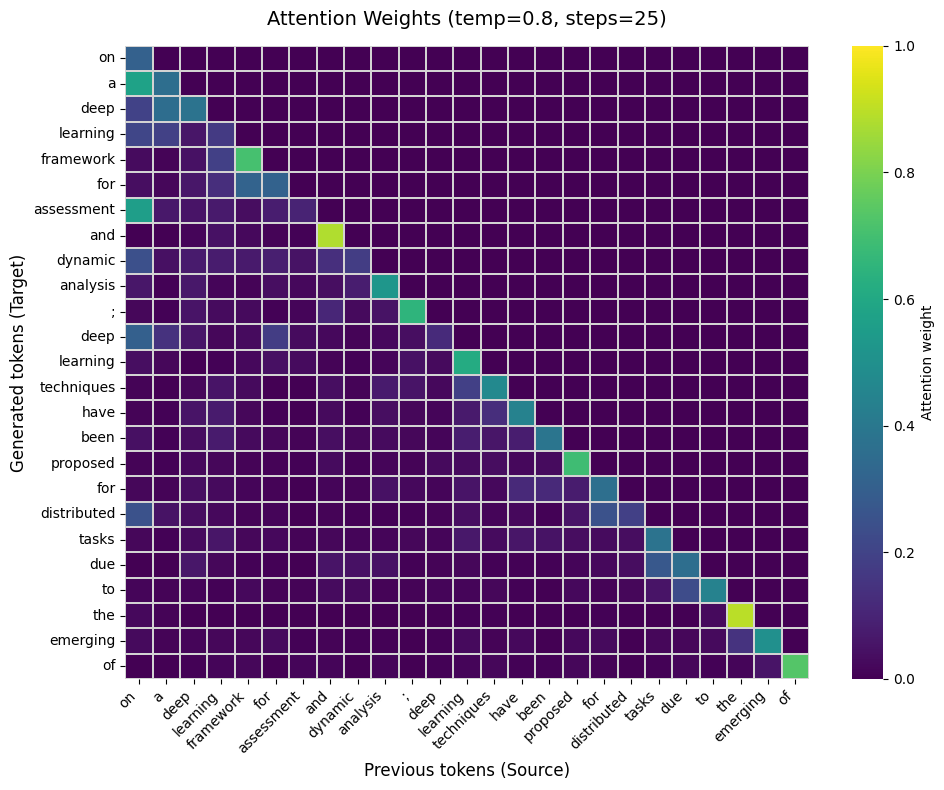

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=0
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

the impact of approximate integration in the eu robots ; abstract the rapid development of the internet of things , the adoption of the forms


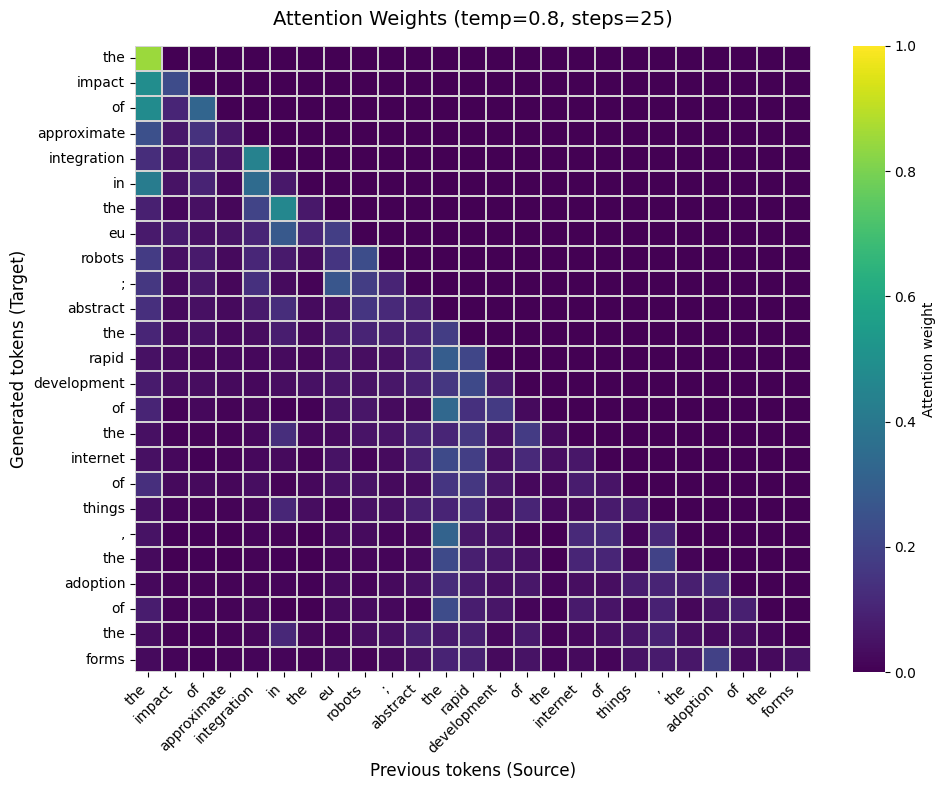

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=1
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

effects : a comparative study of the concept of a case study ; the authors of the purpose of the development of the americas chapter


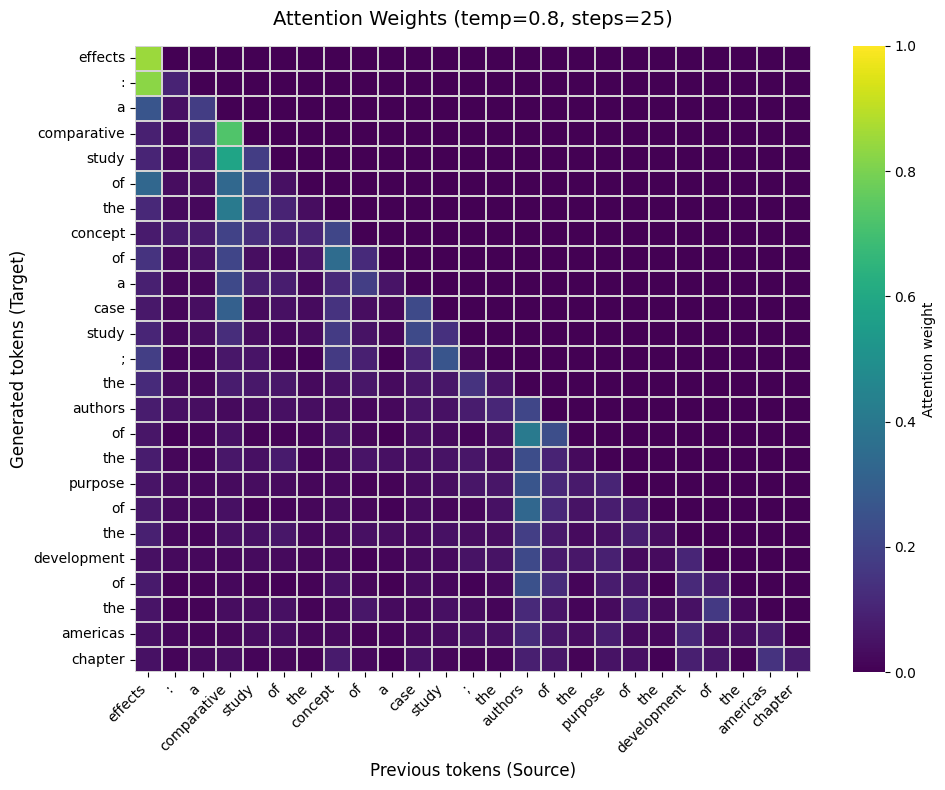

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=1
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

the satisfaction of master protection in the field of polycyclic education ; abstract the rise of the increasing complexity of artificial intelligence ( ai )


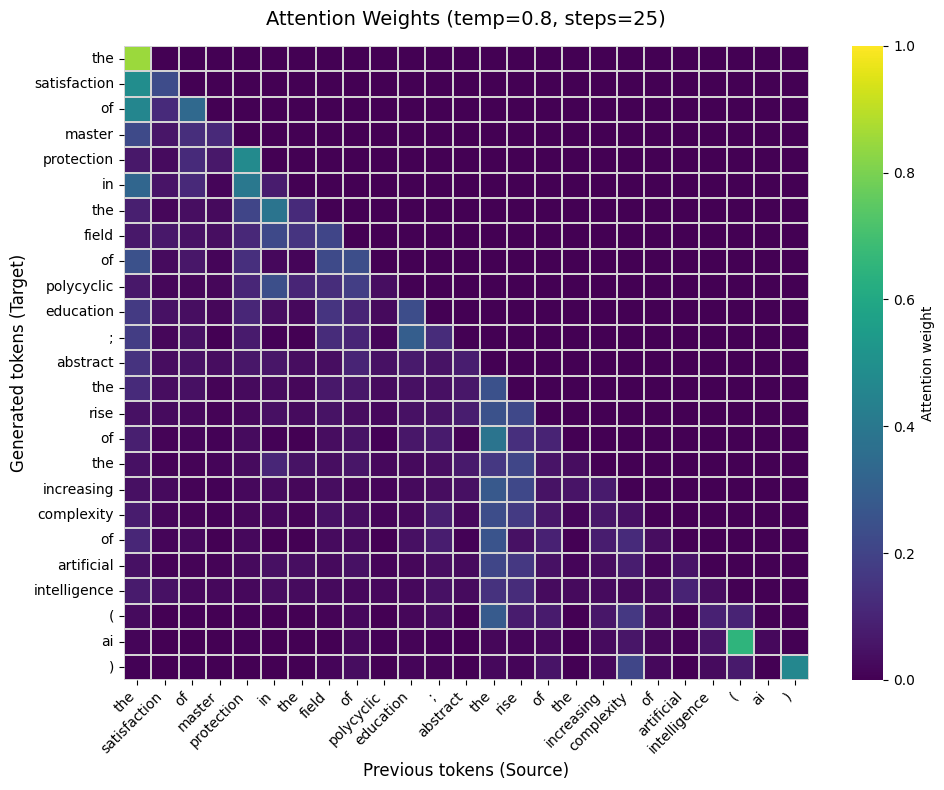

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=1
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

: a system of llm - based multi - agent federated learning ( fl ) ; collaborative fl of long - agent reinforcement learning (


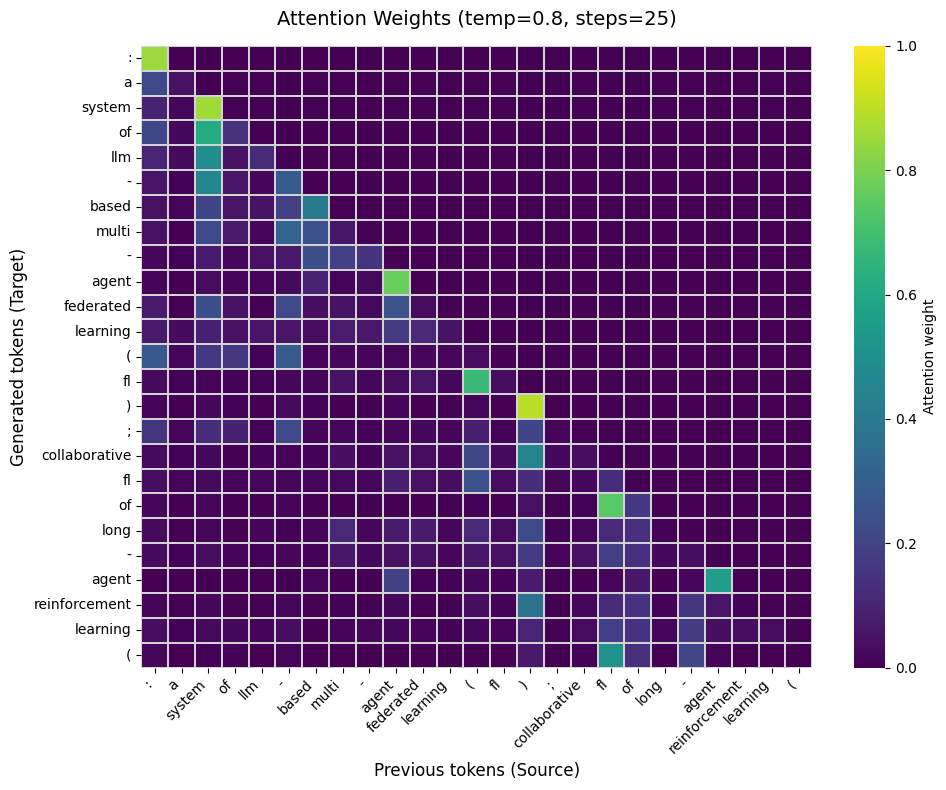

In [ ]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=-1
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

a hybrid - centric - channel algorithm for breast cancer diagnosis ; the proliferation of constitutional medical imaging ( nlp ) involves natural language processing


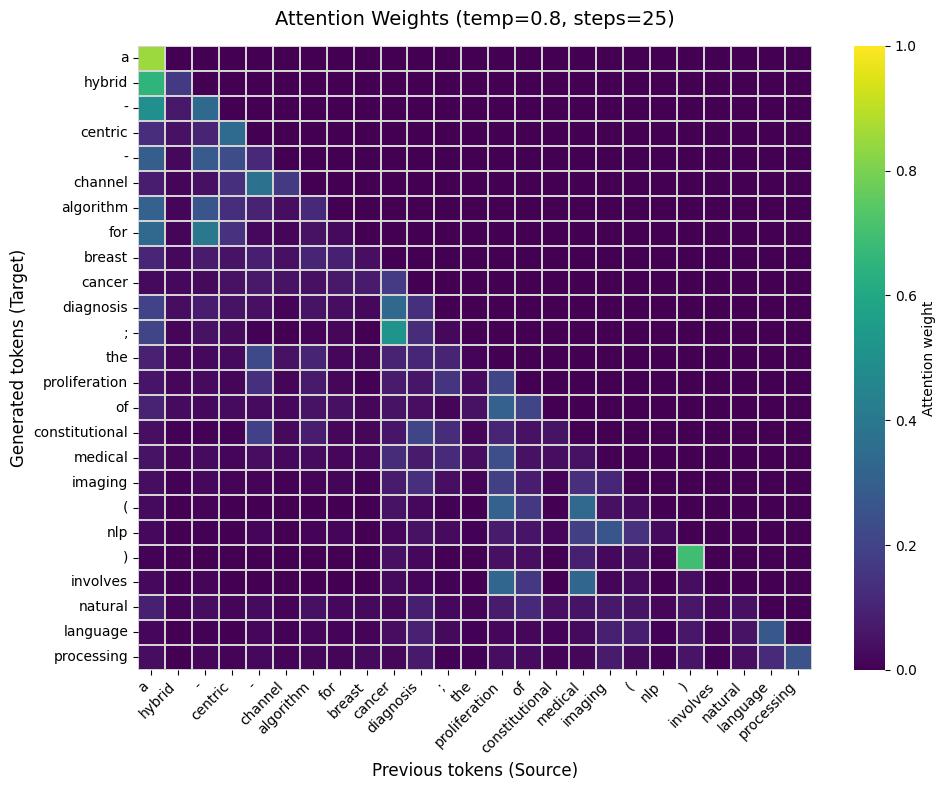

In [54]:
prefix = BOS
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=-1
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

on the use of artificial intelligence in digital media platforms of this study on the impact of the 21st of artificial intelligence ; the article


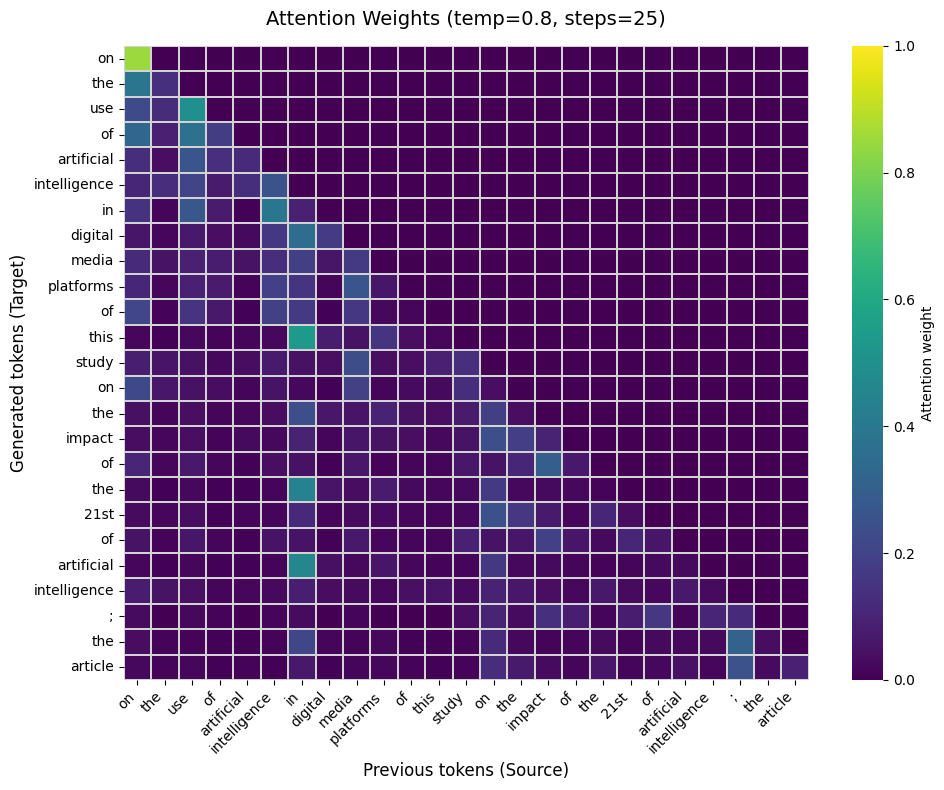

In [55]:
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=-1
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

this project presents a novel framework that combines the approach of the logic of cognitive states on the performance of the internet of things (


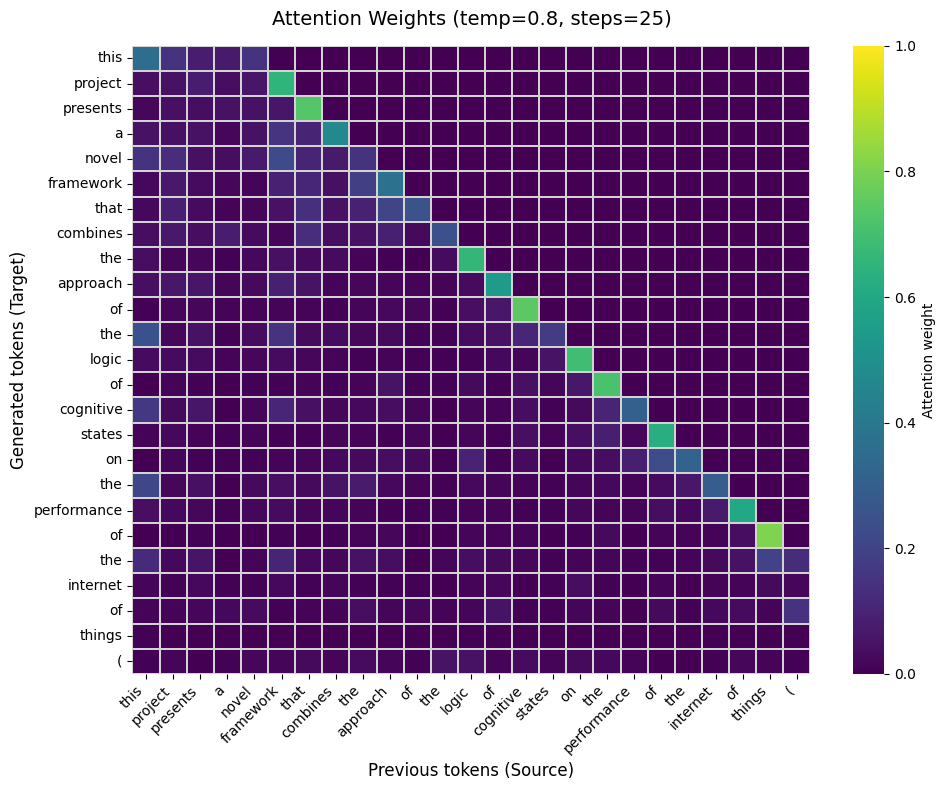

In [56]:
prefix = 'LLM - based models ; '
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=0
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

abstract we present the extent of the art of the increasing complexity of a pivotal role of large language models ( llms ), which is


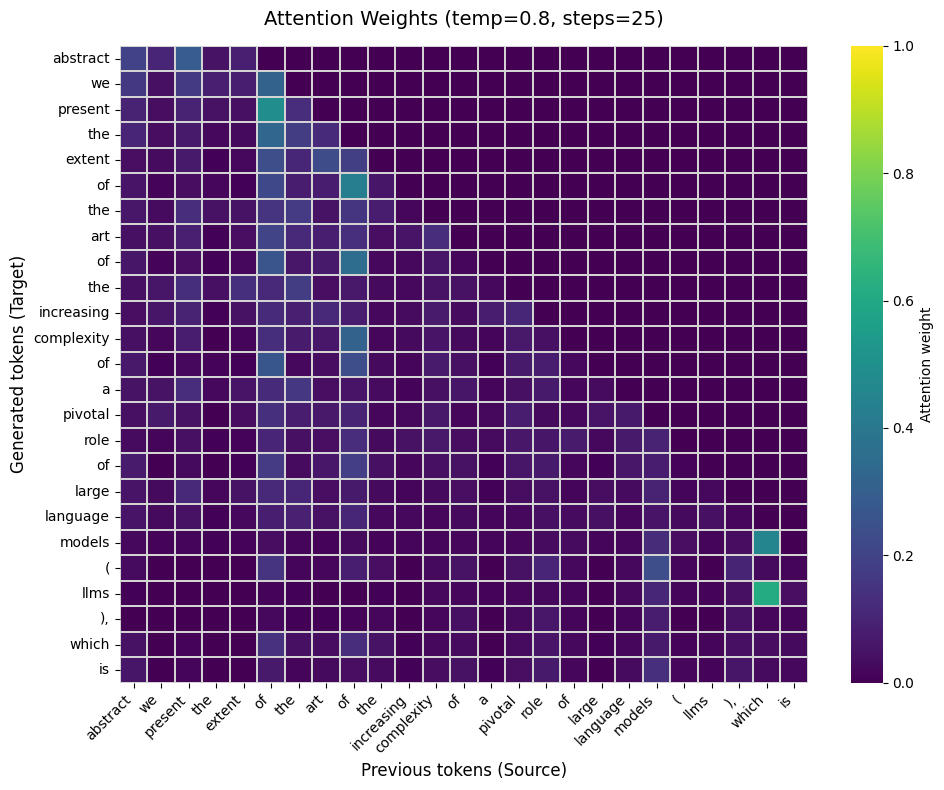

In [57]:
prefix = 'LLM - based models ; '
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=1
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

the development of the nations of the relationship of the americas chapter of the association for ai education in the university and the management of


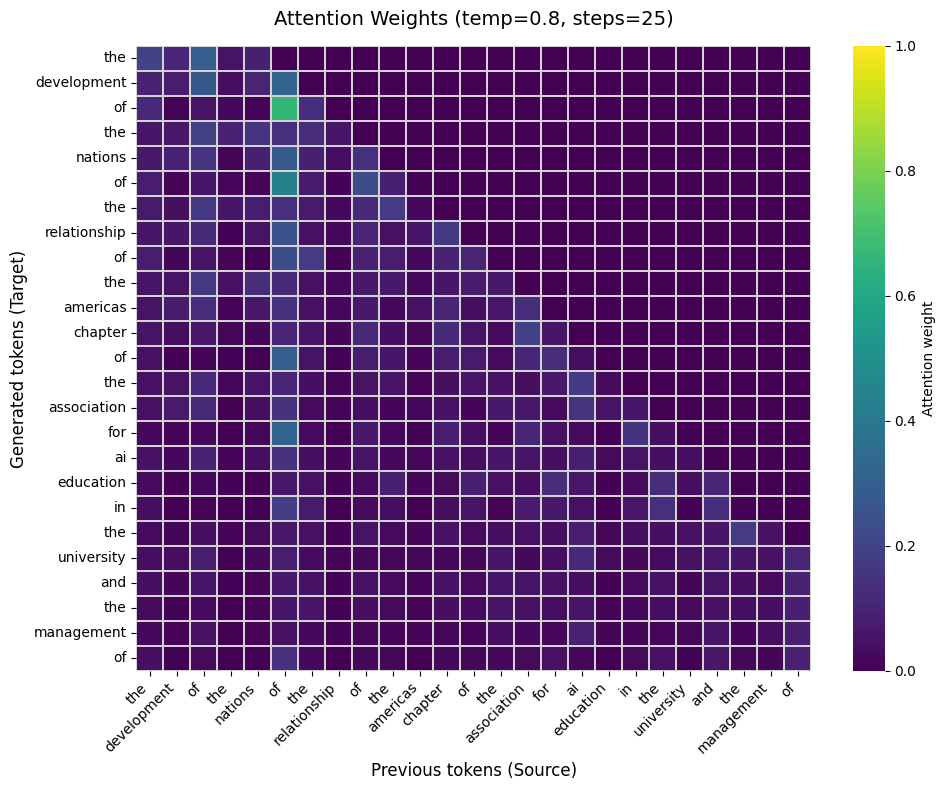

In [58]:
prefix = 'LLM - based models ; '
temperature = 0.8
gen_tokens, attn_mat = generate_with_attention(
    model,
    prefix=prefix,
    temperature=temperature,
    max_len=25,
    device=device,
    layer_idx=-1
)

print(f"{' '.join(gen_tokens)}")

draw_attention(gen_tokens, attn_mat, title=f"Attention Weights (temp={temperature}, steps={len(gen_tokens)})")

**ТУТ ВАШИ СЛОВА ПРО ИНТЕРПРЕТАЦИЮ. ТАК КАК ЗАДАНИЕ В ЭТОМ И СОСТОИТ, ТО ИНТЕРПРЕТАЦИЯ ДОЛЖНА БЫТЬ АДЕКВАТНОЙ, НАДО ПРОВЕСТИ РАЗНЫЕ ЭКСПЕРИМЕНТЫ И ДАТЬ КАКОЙ-ТО ВЫВОД**

# ПРО БЯМ

Если вы использовали БЯМ, то в этом пункте нужно написать небольшой отчет: что с какого раза получилось, для чего использовали, какие изменения и в какой последоваьельности вносили и так далее. А именно: на какие ошибри реагировала БЯМ, что предлагала, меняла ли свое же решение и так далее.  
_Ожидается как минимум 3 абзаца про каждый из пунктов домашки_

Использовал Claude Code.

Когда при визуализации внимания я получил матрицу с нулями везде - спросил клод. Он нашел баг, я брал веса с последней позиции, а там был PAD-токен.
Я пофиксил, потом визуализация улучшилась, но моделька так же генерила бред именно в generate_with_attention, а на осталных генерациях все было норм.
Снова спросил клод. Оказалось, та же проблема была и с логитами - тоже брал с [-1].

Просил объяснить мне, почему что-то работает так, как работает. Он давал мне объяснение. Я читал и с чем-то соглашался, а с чем-то нет. С моментами, с которыми я не соглашался - просил клод перепроверить себя - он проверял и исправлялся) В основном после перепроверки себя на те моменты, которые мне не нравились, клод говорил что-то вроде "Сори, сгенерил бред"


Также, я старался переписывать то, что я понял от клода своими словами, чтобы понять. Где-то свои наблюдения тоже записывал. Затем, просил его оценить и дать критику - иногда давай резонные комментарии.


А еще просил оценить графики обучения и подсказать, как их можно улучшить. Он давал комментарии, я попробовал с помощью него реализовать их в другом блокноте, но получилось не лучше по loss.

Помогал мне писать код) TransformerOnlyLanguageModel сгенерил без ошибок, а в RNN-ке возникла ошибка где-то дальше в коде, из-за чего пришлось перепроверять.